In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths
# -----------------------------
synthetic_file = "data3.csv"                     # synthetic dataset
cal10_file     = "calibration_10_newdata/eplusout.csv"   # 10-zone calibration output
cal3_file      = "calibration_3_newdata/eplusout.csv"    # 3-zone calibration output

# -----------------------------
# Load CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_file)
df_cal10 = pd.read_csv(cal10_file)
df_cal3  = pd.read_csv(cal3_file)

# Clean Date/Time
for df in [df_synth, df_cal10, df_cal3]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Find common zone columns
# -----------------------------
common_cols = [
    c for c in df_synth.columns
    if "Zone Mean Air Temperature" in c
    and c in df_cal10.columns
    and c in df_cal3.columns
]

# -----------------------------
# Merge with explicit suffixes
# -----------------------------
df_merged = df_synth[["Date/Time"] + common_cols] \
    .merge(df_cal10[["Date/Time"] + common_cols], on="Date/Time", suffixes=("", "_cal10")) \
    .merge(df_cal3[["Date/Time"] + common_cols], on="Date/Time", suffixes=("", "_cal3"))

# -----------------------------
# Calculate RMSE per zone
# -----------------------------
rmse_results = []
for col in common_cols:
    y_true  = df_merged[col].astype(float).to_numpy()
    y_cal10 = df_merged[f"{col}_cal10"].astype(float).to_numpy()
    y_cal3  = df_merged[f"{col}_cal3"].astype(float).to_numpy()

    rmse10 = np.sqrt(mean_squared_error(y_true, y_cal10))
    rmse3  = np.sqrt(mean_squared_error(y_true, y_cal3))

    rmse_results.append((col, rmse10, rmse3))

# Create DataFrame
df_rmse = pd.DataFrame(rmse_results, columns=["Zone", "RMSE (10-zone)", "RMSE (3-zone)"])
df_rmse.loc[len(df_rmse)] = [
    "AVERAGE",
    df_rmse["RMSE (10-zone)"].mean(),
    df_rmse["RMSE (3-zone)"].mean()
]

# -----------------------------
# Display results
# -----------------------------
print("\n✅ RMSE Comparison (10-zone vs 3-zone):")
print(df_rmse.to_string(index=False))



✅ RMSE Comparison (10-zone vs 3-zone):
                                                     Zone  RMSE (10-zone)  RMSE (3-zone)
        CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)        0.348307       0.275977
    TOPFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.861531       0.808487
    MIDFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.926696       0.842342
  FIRSTFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.796888       0.702078
           CORE_MID:Zone Mean Air Temperature [C](Hourly)        0.306558       0.252131
           CORE_TOP:Zone Mean Air Temperature [C](Hourly)        0.773502       0.829659
 PERIMETER_TOP_ZN_3:Zone Mean Air Temperature [C](Hourly)        0.792393       0.736886
 PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)        0.539459       0.492082
 PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)        0.422045       0.452341
 PERIMETER_TOP_ZN_4:Zone Mean Air Temperature [C](Hourly)        0.939

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths for calibrated models
# -----------------------------
models = {
    "Calibration_10": "calibration_10_newdata/eplusout.csv",
    "Calibration_3":  "calibration_3_newdata/eplusout.csv"
}
synthetic_file = "data3.csv"

# -----------------------------
# Load synthetic dataset
# -----------------------------
df_synth = pd.read_csv(synthetic_file)
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# -----------------------------
# Collect RMSEs for all models
# -----------------------------
rmse_all = []

for model_name, eplus_output in models.items():
    df_sim = pd.read_csv(eplus_output)
    df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()

    # Find common zone columns
    common_cols = [c for c in df_sim.columns if "Zone Mean Air Temperature" in c and c in df_synth.columns]

    # Merge on Date/Time
    df_merged = pd.merge(
        df_sim[["Date/Time"] + common_cols],
        df_synth[["Date/Time"] + common_cols],
        on="Date/Time",
        suffixes=("_sim", "_syn")
    )

    # Compute RMSE per zone
    for col in common_cols:
        sim_values = df_merged[f"{col}_sim"].astype(float).to_numpy()
        synth_values = df_merged[f"{col}_syn"].astype(float).to_numpy()
        rmse = np.sqrt(mean_squared_error(synth_values, sim_values))
        rmse_all.append((model_name, col, rmse))

# -----------------------------
# Create DataFrame for display
# -----------------------------
df_rmse = pd.DataFrame(rmse_all, columns=["Model", "Zone", "RMSE (°C)"])

# Add average RMSE per model
avg_rmse = df_rmse.groupby("Model")["RMSE (°C)"].mean().reset_index()
avg_rmse["Zone"] = "AVERAGE"
df_rmse = pd.concat([df_rmse, avg_rmse], ignore_index=True)

# -----------------------------
# Display results in pivot form
# -----------------------------
print("\n✅ RMSE per Zone and Model:")
print(df_rmse.pivot(index="Zone", columns="Model", values="RMSE (°C)").to_string())



✅ RMSE per Zone and Model:
Model                                                      Calibration_10  Calibration_3
Zone                                                                                    
AVERAGE                                                          0.598361       0.585916
CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)                0.348307       0.275977
CORE_MID:Zone Mean Air Temperature [C](Hourly)                   0.306558       0.252131
CORE_TOP:Zone Mean Air Temperature [C](Hourly)                   0.773502       0.829659
FIRSTFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)          0.796888       0.702078
MIDFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)            0.926696       0.842342
PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)         0.503878       0.574973
PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)         0.513722       0.606178
PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)         0.259397       0.

In [15]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths for calibrated models
# -----------------------------
models = {
    "Calibration_10": "calibration_10_newdata/eplusout.csv",
    "Calibration_3":  "calibration_3_newdata/eplusout.csv"
}
synthetic_file = "data3.csv"

# -----------------------------
# Top 10 zones of interest
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# -----------------------------
# Load synthetic dataset
# -----------------------------
df_synth = pd.read_csv(synthetic_file)
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# -----------------------------
# Collect RMSEs for all models
# -----------------------------
rmse_all = []

for model_name, eplus_output in models.items():
    df_sim = pd.read_csv(eplus_output)
    df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()

    # Restrict to top 10 common zone columns
    common_cols = [c for c in TOP10_ZONES if c in df_sim.columns and c in df_synth.columns]

    # Merge on Date/Time
    df_merged = pd.merge(
        df_sim[["Date/Time"] + common_cols],
        df_synth[["Date/Time"] + common_cols],
        on="Date/Time",
        suffixes=("_sim", "_syn")
    )

    # Compute RMSE per zone
    for col in common_cols:
        sim_values = df_merged[f"{col}_sim"].astype(float).to_numpy()
        synth_values = df_merged[f"{col}_syn"].astype(float).to_numpy()
        rmse = np.sqrt(mean_squared_error(synth_values, sim_values))
        rmse_all.append((model_name, col, rmse))

# -----------------------------
# Create DataFrame for display
# -----------------------------
df_rmse = pd.DataFrame(rmse_all, columns=["Model", "Zone", "RMSE (°C)"])

# Add average RMSE per model
avg_rmse = df_rmse.groupby("Model")["RMSE (°C)"].mean().reset_index()
avg_rmse["Zone"] = "AVERAGE"
df_rmse = pd.concat([df_rmse, avg_rmse], ignore_index=True)

# Pivot table
df_pivot = df_rmse.pivot(index="Zone", columns="Model", values="RMSE (°C)")

# Reorder so "AVERAGE" is last
df_pivot = df_pivot.reindex([z for z in TOP10_ZONES if z in df_pivot.index] + ["AVERAGE"])

# -----------------------------
# Display results
# -----------------------------
print("\n✅ RMSE for Top 10 Zones and Models:")
print(df_pivot.to_string())



✅ RMSE for Top 10 Zones and Models:
Model                                                     Calibration_10  Calibration_3
Zone                                                                                   
PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)        0.259397       0.216319
PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)        0.230315       0.214788
CORE_MID:Zone Mean Air Temperature [C](Hourly)                  0.306558       0.252131
PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)        0.237111       0.229951
CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)               0.348307       0.275977
PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)        0.539459       0.492082
PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)        0.422045       0.452341
PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)        0.503878       0.574973
PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)        0.513722       0.60

In [16]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths for calibrated models
# -----------------------------
models = {
    "Calibration_10": "calibration_10_newdata/eplusout.csv",
    "Calibration_3":  "calibration_3_newdata/eplusout.csv"
}
synthetic_file = "data3.csv"

# -----------------------------
# Top 10 zones of interest
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)"
]

# -----------------------------
# Load synthetic dataset
# -----------------------------
df_synth = pd.read_csv(synthetic_file)
df_synth["Date/Time"] = df_synth["Date/Time"].astype(str).str.strip()

# -----------------------------
# Collect RMSEs for all models
# -----------------------------
rmse_all = []

for model_name, eplus_output in models.items():
    df_sim = pd.read_csv(eplus_output)
    df_sim["Date/Time"] = df_sim["Date/Time"].astype(str).str.strip()

    # Restrict to top 10 common zone columns
    common_cols = [c for c in TOP10_ZONES if c in df_sim.columns and c in df_synth.columns]

    # Merge on Date/Time
    df_merged = pd.merge(
        df_sim[["Date/Time"] + common_cols],
        df_synth[["Date/Time"] + common_cols],
        on="Date/Time",
        suffixes=("_sim", "_syn")
    )

    # Compute RMSE per zone
    for col in common_cols:
        sim_values = df_merged[f"{col}_sim"].astype(float).to_numpy()
        synth_values = df_merged[f"{col}_syn"].astype(float).to_numpy()
        rmse = np.sqrt(mean_squared_error(synth_values, sim_values))
        rmse_all.append((model_name, col, rmse))

# -----------------------------
# Create DataFrame for display
# -----------------------------
df_rmse = pd.DataFrame(rmse_all, columns=["Model", "Zone", "RMSE (°C)"])

# Add average RMSE per model
avg_rmse = df_rmse.groupby("Model")["RMSE (°C)"].mean().reset_index()
avg_rmse["Zone"] = "AVERAGE"
df_rmse = pd.concat([df_rmse, avg_rmse], ignore_index=True)

# Pivot table
df_pivot = df_rmse.pivot(index="Zone", columns="Model", values="RMSE (°C)")

# Reorder so "AVERAGE" is last
df_pivot = df_pivot.reindex([z for z in TOP10_ZONES if z in df_pivot.index] + ["AVERAGE"])

# -----------------------------
# Display results
# -----------------------------
print("\n✅ RMSE for Top 10 Zones and Models:")
print(df_pivot.to_string())



✅ RMSE for Top 10 Zones and Models:
Model                                                     Calibration_10  Calibration_3
Zone                                                                                   
PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)        0.230315       0.214788
PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)        0.237111       0.229951
PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)        0.259397       0.216319
AVERAGE                                                         0.242274       0.220353


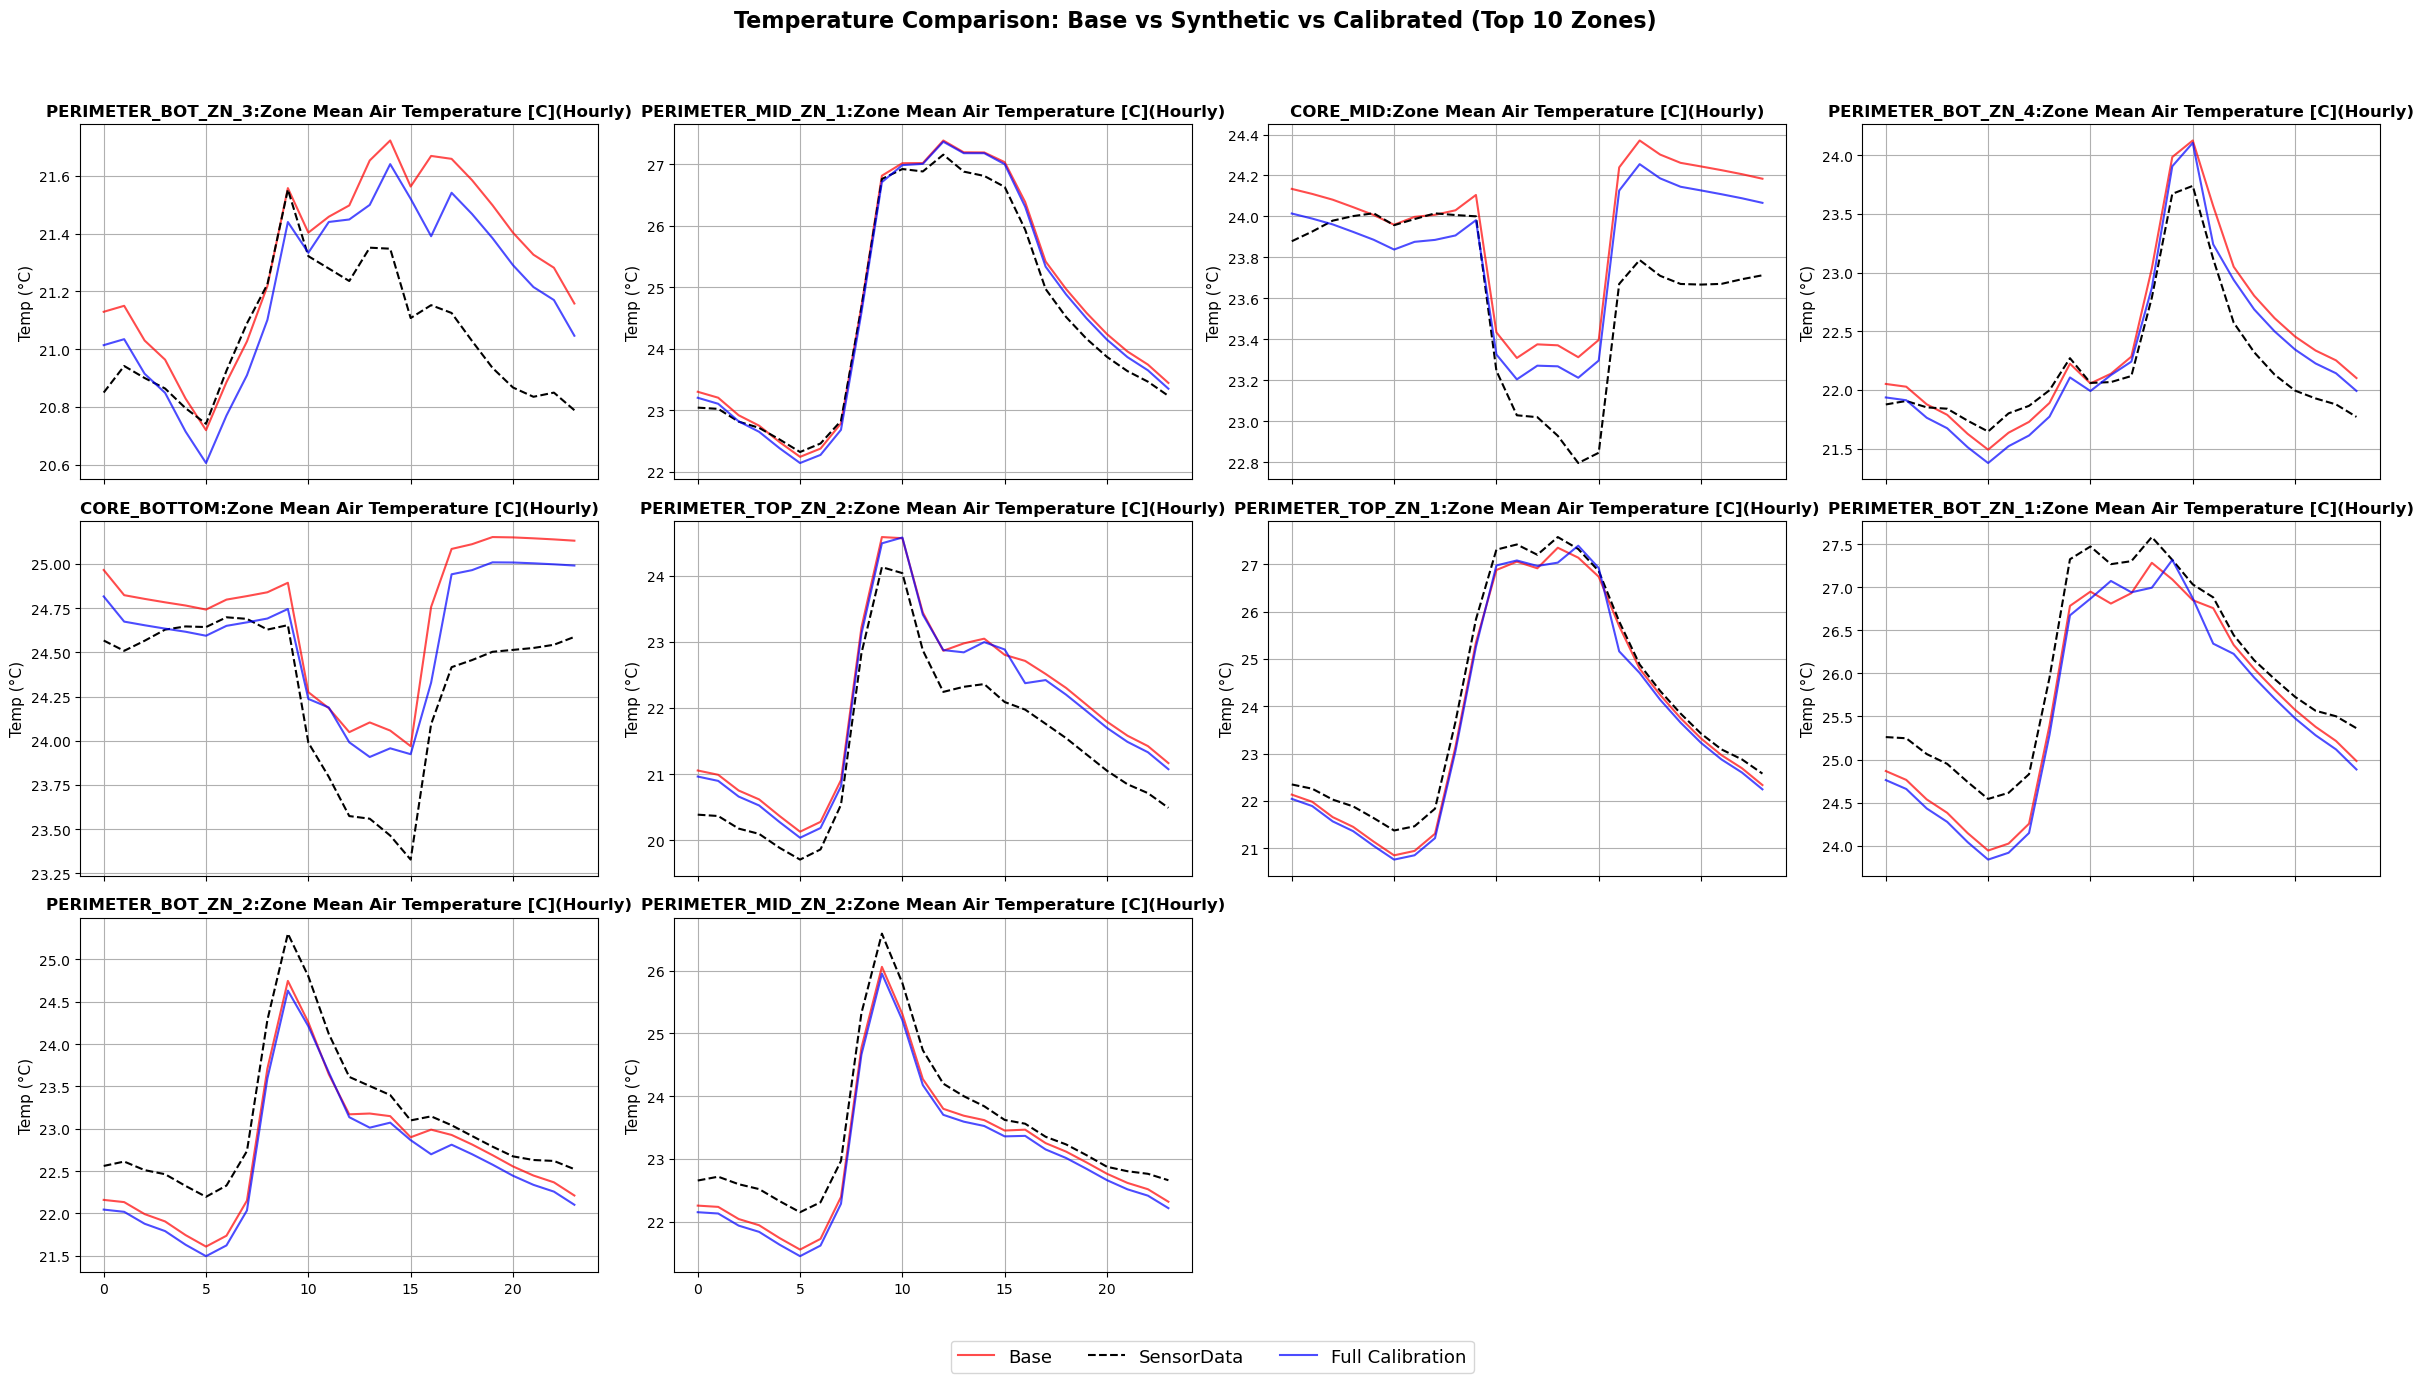

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
synthetic_csv   = "data3.csv"                          
base_csv        = "model.csv"    
calibrated_csv  = "calibration_10_newdata/eplusout.csv"

# -----------------------------
# Load all CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Clean Date/Time
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Top 10 zones of interest
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Keep only available zones
zone_cols = [z for z in TOP10_ZONES if z in df_base.columns]

# -----------------------------
# Merge base, synth, and calibrated on Date/Time
# -----------------------------
df_merged = df_base[["Date/Time"] + zone_cols].merge(
    df_synth[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated columns
rename_map = {c: c + "_cal" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting only the top 10 zones (3 rows × 4 columns)
# -----------------------------
fig, axes = plt.subplots(3, 4, figsize=(24, 14), sharex=True)  # 3 rows × 4 cols
axes = axes.flatten()

for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="SensorData", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal"], label="Full Calibration", color="blue", alpha=0.7)
    ax.set_title(zone, fontsize=12, fontweight="bold")
    ax.set_ylabel("Temp (°C)", fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True)

# Hide unused subplots (12 slots – 10 zones = 2 empty)
for j in range(len(zone_cols), len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

plt.suptitle("Temperature Comparison: Base vs Synthetic vs Calibrated (Top 10 Zones)", 
             fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_top10.png", dpi=300, bbox_inches="tight")
plt.show()


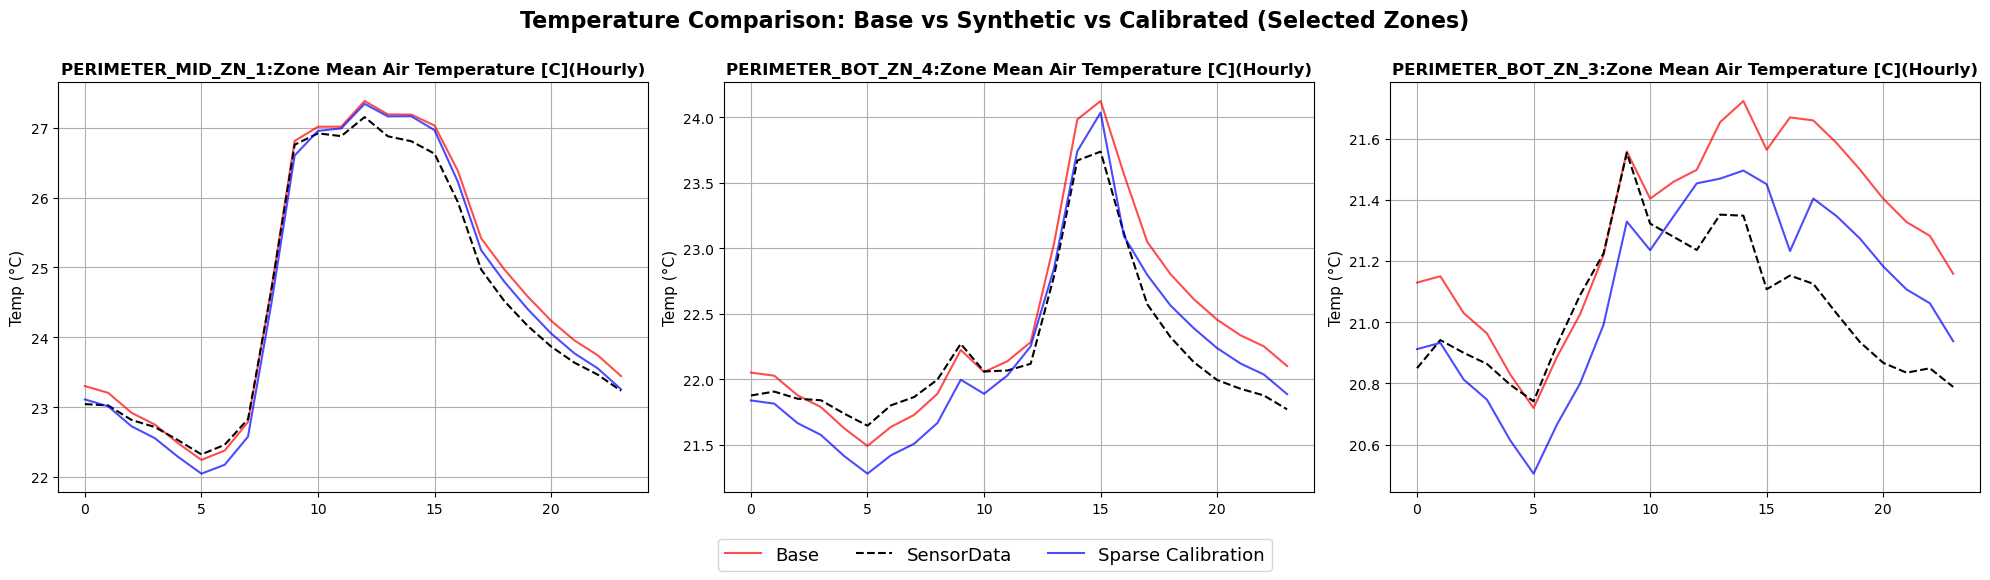

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
synthetic_csv   = "data3.csv"                          
base_csv        = "model.csv"    
calibrated_csv  = "calibration_3_newdata/eplusout.csv"

# -----------------------------
# Load all CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_csv)
df_base  = pd.read_csv(base_csv)
df_cal   = pd.read_csv(calibrated_csv)

# Clean Date/Time
for df in [df_synth, df_base, df_cal]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Selected zones of interest
# -----------------------------
SELECTED_ZONES = [
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)"
]

# Keep only available zones
zone_cols = [z for z in SELECTED_ZONES if z in df_base.columns]

# -----------------------------
# Merge base, synth, and calibrated on Date/Time
# -----------------------------
df_merged = df_base[["Date/Time"] + zone_cols].merge(
    df_synth[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_base", "_synth")
).merge(
    df_cal[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated columns
rename_map = {c: c + "_cal" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting only the selected zones (1 row × 3 columns)
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharex=True)  # 1 row × 3 cols
axes = axes.flatten()

for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="SensorData", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal"], label="Sparse Calibration", color="blue", alpha=0.7)
    ax.set_title(zone, fontsize=12, fontweight="bold")
    ax.set_ylabel("Temp (°C)", fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True)

# Hide unused subplots if fewer than 3 zones are found
for j in range(len(zone_cols), len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

plt.suptitle("Temperature Comparison: Base vs Synthetic vs Calibrated (Selected Zones)", 
             fontsize=16, fontweight="bold", y=0.95)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_selected3.png", dpi=300, bbox_inches="tight")
plt.show()


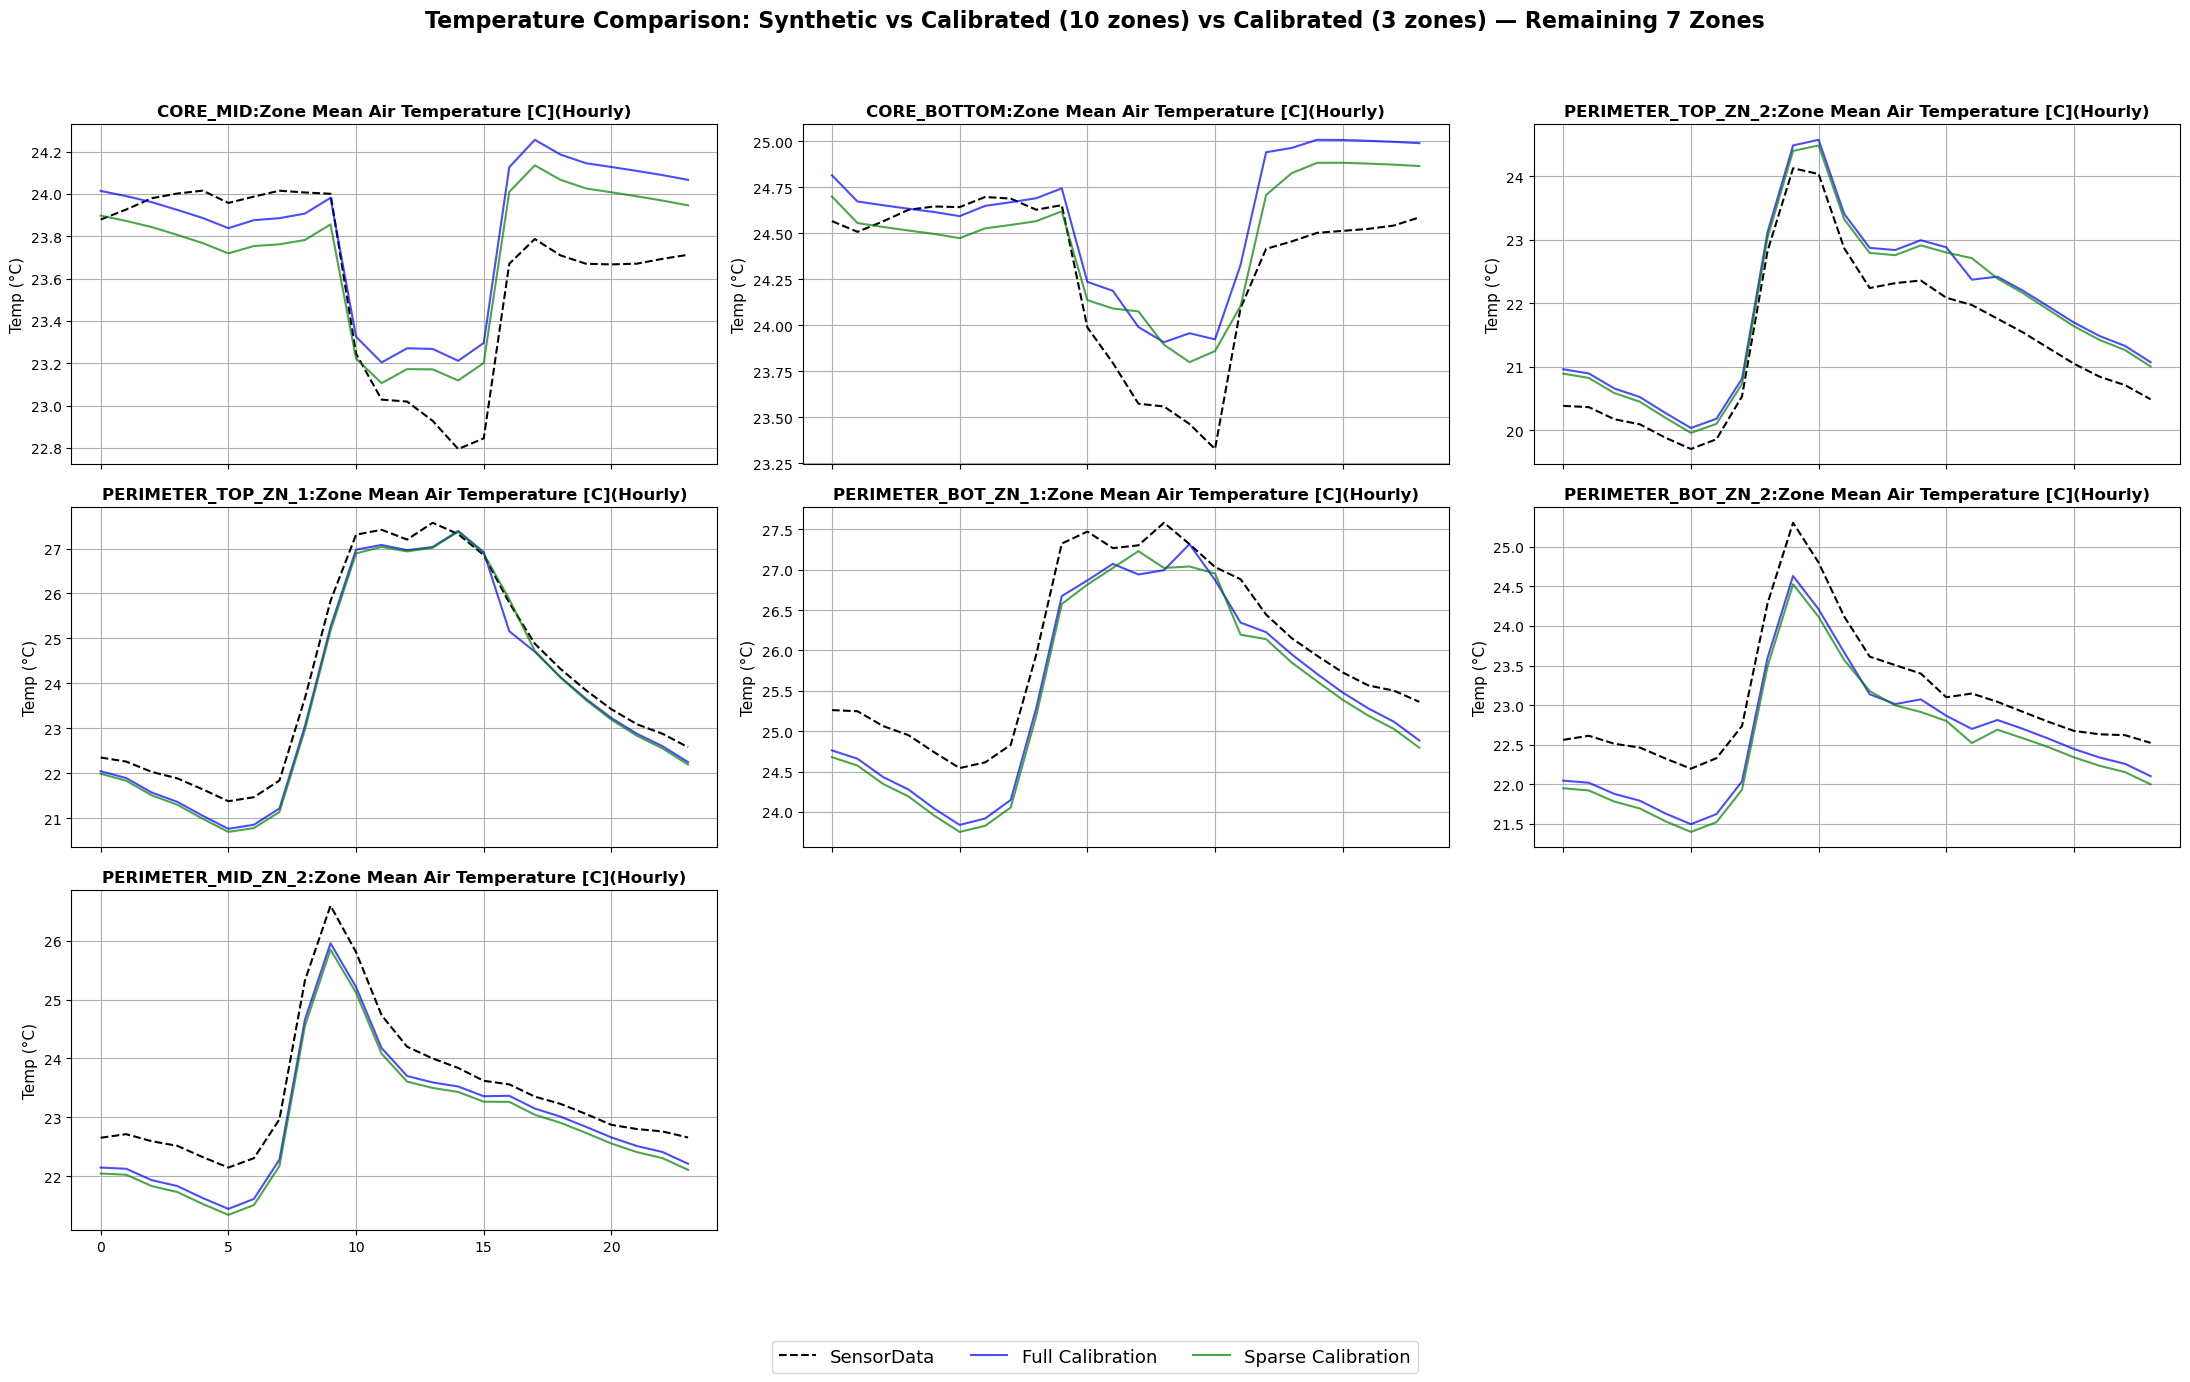

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths (adjust if needed)
# -----------------------------
synthetic_csv     = "data3.csv"                          
calibrated_10_csv = "calibration_10_newdata/eplusout.csv"
calibrated_3_csv  = "calibration_3_newdata/eplusout.csv"

# -----------------------------
# Load all CSVs
# -----------------------------
df_synth = pd.read_csv(synthetic_csv)
df_cal10 = pd.read_csv(calibrated_10_csv)
df_cal3  = pd.read_csv(calibrated_3_csv)

# Clean Date/Time
for df in [df_synth, df_cal10, df_cal3]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Selected zones = the other 7 from the Top 10
# -----------------------------
SELECTED_ZONES = [
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Keep only available zones
zone_cols = [z for z in SELECTED_ZONES if z in df_cal10.columns and z in df_cal3.columns and z in df_synth.columns]

# -----------------------------
# Merge synthetic, cal10, cal3 on Date/Time
# -----------------------------
df_merged = df_synth[["Date/Time"] + zone_cols].merge(
    df_cal10[["Date/Time"] + zone_cols], on="Date/Time", suffixes=("_synth", "_cal10")
).merge(
    df_cal3[["Date/Time"] + zone_cols], on="Date/Time"
)

# Rename calibrated 3-zone columns
rename_map = {c: c + "_cal3" for c in zone_cols}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting selected zones (3 rows × 3 columns for 7 zones)
# -----------------------------
fig, axes = plt.subplots(3, 3, figsize=(22, 14), sharex=True)  
axes = axes.flatten()

for i, zone in enumerate(zone_cols):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_synth"], label="SensorData", color="black", linestyle="--")
    ax.plot(df_merged.index, df_merged[f"{zone}_cal10"], label="Full Calibration", color="blue", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_cal3"], label="Sparse Calibration", color="green", alpha=0.7)
    ax.set_title(zone, fontsize=12, fontweight="bold")
    ax.set_ylabel("Temp (°C)", fontsize=11)
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.grid(True)

# Hide unused subplots (9 slots – 7 zones = 2 empty)
for j in range(len(zone_cols), len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=13)

plt.suptitle("Temperature Comparison: Synthetic vs Calibrated (10 zones) vs Calibrated (3 zones) — Remaining 7 Zones", 
             fontsize=16, fontweight="bold", y=0.98)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_cal10_vs_cal3_7zones.png", dpi=300, bbox_inches="tight")
plt.show()


In [21]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error

# -----------------------------
# File paths
# -----------------------------
base_csv        = "model.csv"    
calibrated_10   = "calibration_10_newdata/eplusout.csv"
calibrated_3    = "calibration_3_newdata/eplusout.csv"

# -----------------------------
# Load CSVs
# -----------------------------
df_base = pd.read_csv(base_csv)
df_cal10 = pd.read_csv(calibrated_10)
df_cal3  = pd.read_csv(calibrated_3)

# Clean Date/Time
for df in [df_base, df_cal10, df_cal3]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Define Top 10 zones (to exclude)
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Identify all zone columns
all_zones = [c for c in df_base.columns if "Zone Mean Air Temperature" in c]

# Bottom 8 = zones not in Top 10
bottom8_zones = [z for z in all_zones if z not in TOP10_ZONES]

# -----------------------------
# Merge datasets
# -----------------------------
df_merged = df_base[["Date/Time"] + bottom8_zones].merge(
    df_cal10[["Date/Time"] + bottom8_zones], on="Date/Time", suffixes=("_base", "_cal10")
).merge(
    df_cal3[["Date/Time"] + bottom8_zones], on="Date/Time"
)

# Rename Cal-3 columns
rename_map = {c: c + "_cal3" for c in bottom8_zones}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Compute RMSE for each zone
# -----------------------------
rmse_results = []
for zone in bottom8_zones:
    base = df_merged[f"{zone}_base"].astype(float).to_numpy()
    cal10 = df_merged[f"{zone}_cal10"].astype(float).to_numpy()
    cal3  = df_merged[f"{zone}_cal3"].astype(float).to_numpy()

    rmse_cal10 = np.sqrt(mean_squared_error(base, cal10))
    rmse_cal3  = np.sqrt(mean_squared_error(base, cal3))

    rmse_results.append((zone, rmse_cal10, rmse_cal3))

# -----------------------------
# Convert to DataFrame
# -----------------------------
df_rmse = pd.DataFrame(rmse_results, columns=["Zone", "Calibration_10", "Calibration_3"])

# Compute average row
avg_row = ["AVERAGE", df_rmse["Calibration_10"].mean(), df_rmse["Calibration_3"].mean()]
df_rmse.loc[len(df_rmse)] = avg_row

# -----------------------------
# Display
# -----------------------------
print("\n✅ RMSE for Bottom 8 Zones (Base vs Calibrated Models):")
print(df_rmse.to_string(index=False))



✅ RMSE for Bottom 8 Zones (Base vs Calibrated Models):
                                                     Zone  Calibration_10  Calibration_3
    TOPFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.090459       0.147891
    MIDFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.101575       0.186255
  FIRSTFLOOR_PLENUM:Zone Mean Air Temperature [C](Hourly)        0.118938       0.214948
           CORE_TOP:Zone Mean Air Temperature [C](Hourly)        0.142544       0.176110
 PERIMETER_TOP_ZN_3:Zone Mean Air Temperature [C](Hourly)        0.111311       0.157095
 PERIMETER_TOP_ZN_4:Zone Mean Air Temperature [C](Hourly)        0.120337       0.153340
 PERIMETER_MID_ZN_3:Zone Mean Air Temperature [C](Hourly)        0.104010       0.206572
PERIMETER_MID_ZN_4:Zone Mean Air Temperature [C](Hourly)         0.101929       0.203508
                                                  AVERAGE        0.111388       0.180715


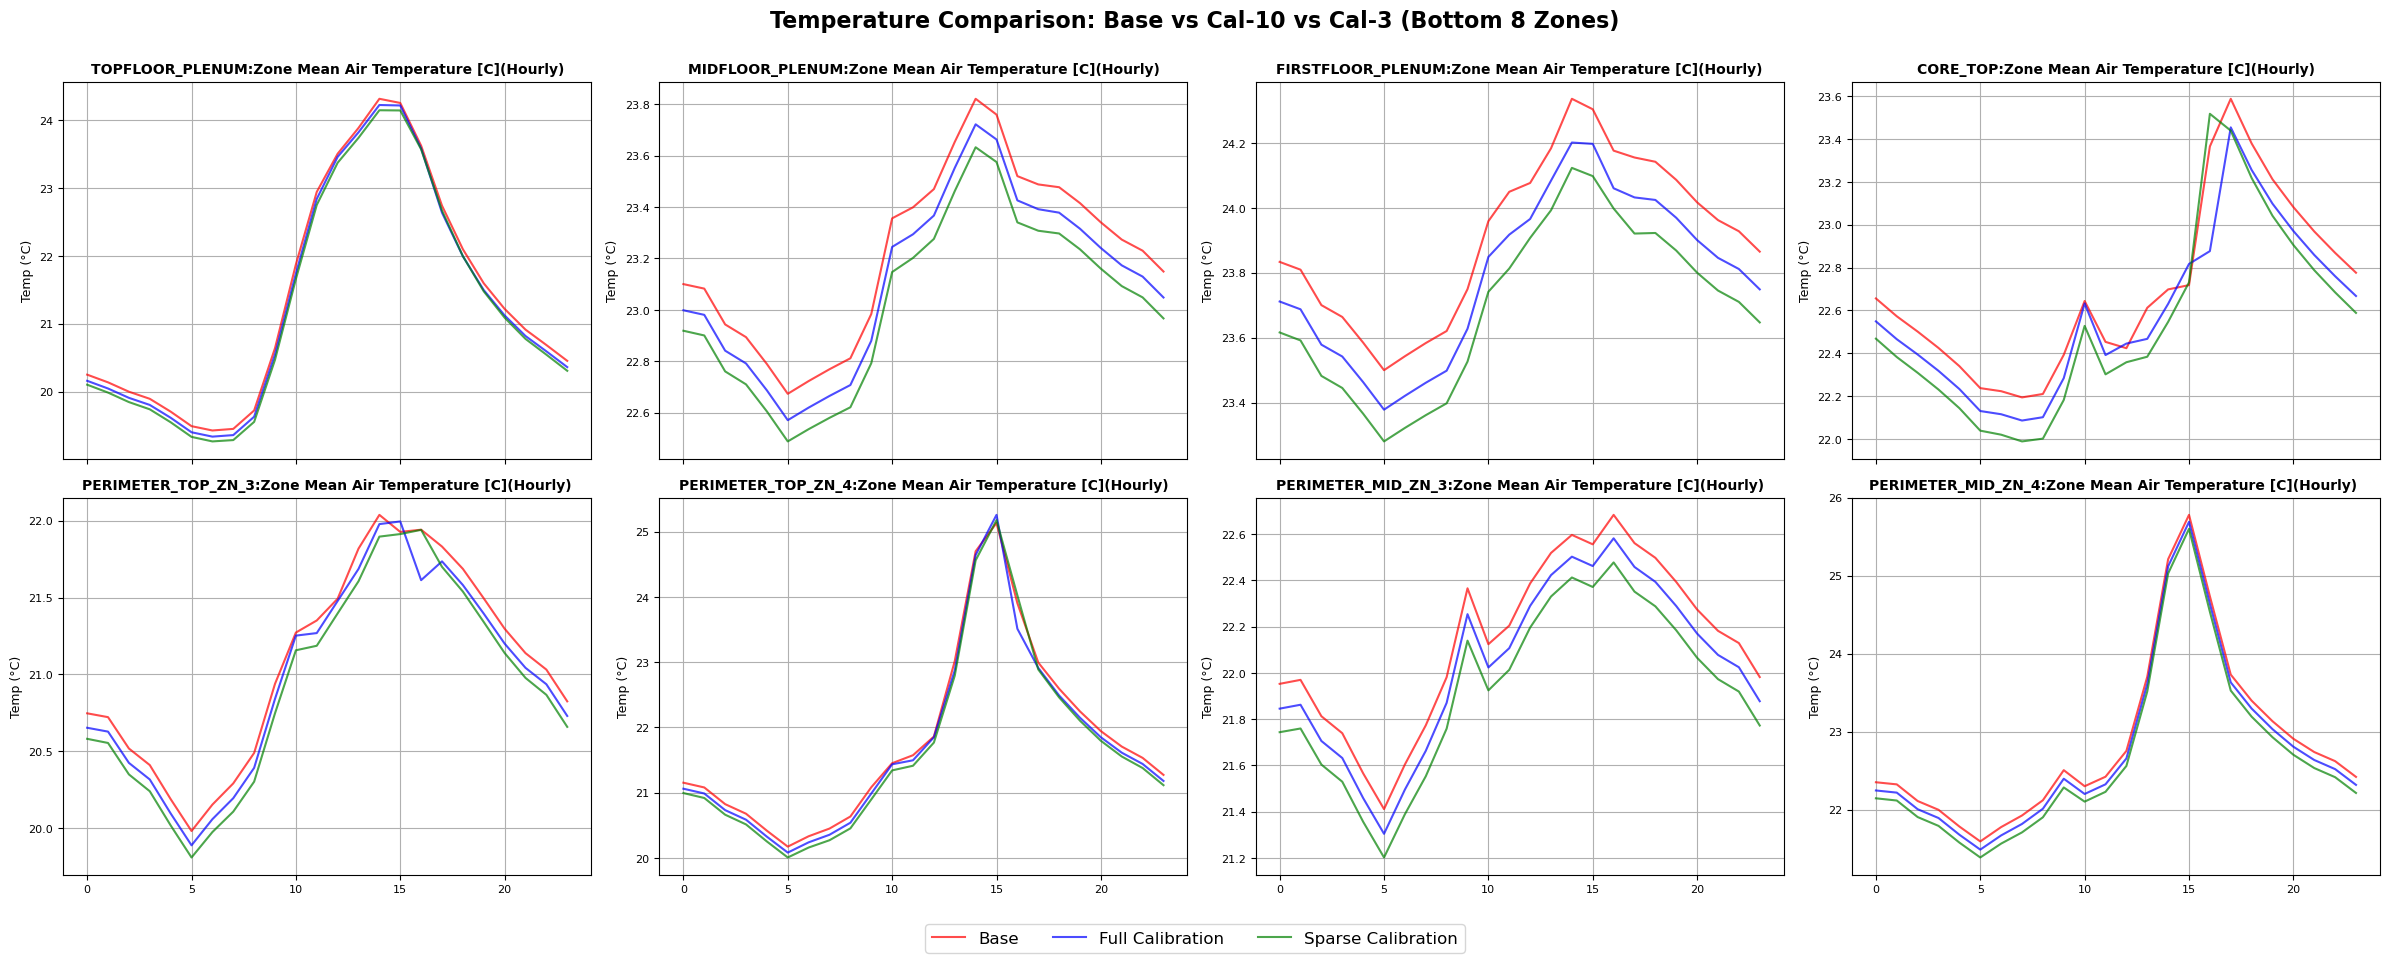

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# File paths
# -----------------------------
base_csv        = "model.csv"    
calibrated_10   = "calibration_10_newdata/eplusout.csv"
calibrated_3    = "calibration_3_newdata/eplusout.csv"

# -----------------------------
# Load CSVs
# -----------------------------
df_base = pd.read_csv(base_csv)
df_cal10 = pd.read_csv(calibrated_10)
df_cal3  = pd.read_csv(calibrated_3)

# Clean Date/Time
for df in [df_base, df_cal10, df_cal3]:
    df["Date/Time"] = df["Date/Time"].astype(str).str.strip()

# -----------------------------
# Define Top 10 zones (exclude them)
# -----------------------------
TOP10_ZONES = [
    "PERIMETER_BOT_ZN_3:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "CORE_MID:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_4:Zone Mean Air Temperature [C](Hourly)",
    "CORE_BOTTOM:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_TOP_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_1:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_BOT_ZN_2:Zone Mean Air Temperature [C](Hourly)",
    "PERIMETER_MID_ZN_2:Zone Mean Air Temperature [C](Hourly)"
]

# Identify all zone columns
all_zones = [c for c in df_base.columns if "Zone Mean Air Temperature" in c]

# Bottom 8 = zones not in Top 10
bottom8_zones = [z for z in all_zones if z not in TOP10_ZONES]

# -----------------------------
# Merge datasets
# -----------------------------
df_merged = df_base[["Date/Time"] + bottom8_zones].merge(
    df_cal10[["Date/Time"] + bottom8_zones], on="Date/Time", suffixes=("_base", "_cal10")
).merge(
    df_cal3[["Date/Time"] + bottom8_zones], on="Date/Time"
)

# Rename Cal-3 columns
rename_map = {c: c + "_cal3" for c in bottom8_zones}
df_merged.rename(columns=rename_map, inplace=True)

# -----------------------------
# Plotting (2 rows × 4 columns)
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True)
axes = axes.flatten()

for i, zone in enumerate(bottom8_zones):
    ax = axes[i]
    ax.plot(df_merged.index, df_merged[f"{zone}_base"], label="Base", color="red", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_cal10"], label="Full Calibration", color="blue", alpha=0.7)
    ax.plot(df_merged.index, df_merged[f"{zone}_cal3"], label="Sparse Calibration", color="green", alpha=0.7)
    ax.set_title(zone, fontsize=10, fontweight="bold")
    ax.set_ylabel("Temp (°C)", fontsize=9)
    ax.tick_params(axis="both", which="major", labelsize=8)
    ax.grid(True)

# Hide unused subplots if fewer than 8
for j in range(len(bottom8_zones), len(axes)):
    fig.delaxes(axes[j])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12)

plt.suptitle("Temperature Comparison: Base vs Cal-10 vs Cal-3 (Bottom 8 Zones)", 
             fontsize=16, fontweight="bold", y=0.95)

plt.tight_layout(rect=[0, 0.05, 1, 0.95])

# -----------------------------
# Save and show
# -----------------------------
plt.savefig("temperature_comparison_bottom8.png", dpi=300, bbox_inches="tight")
plt.show()
